In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_with_selected_features_and_all_outliers = pd.read_csv("../data/data_cleaned_selected_with_all_outliers.csv", index_col=0)
df_with_selected_features_and_no_outliers = pd.read_csv("../data/data_cleaned_selected_with_no_outliers.csv", index_col=0)
df_with_all_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_with_no_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_no_outliers_and_all_features.csv", index_col=0)
print("Data Shape of df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.shape)
print("Data Shape of df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.shape)
print("Data Shape of df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.shape)
print("Data Shape of df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.shape)

Data Shape of df_with_selected_features_and_all_outliers:  (4424, 6)
Data Shape of df_with_selected_features_and_no_outliers:  (4335, 6)
Data Shape of df_with_all_outliers_and_all_features:  (4424, 35)
Data Shape of df_with_no_outliers_and_all_features:  (4335, 35)


In [3]:
print("Columns in df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.columns)
print("Columns in df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.columns)

Columns in df_with_selected_features_and_all_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')
Columns in df_with_selected_features_and_no_outliers:  Index(['Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (enrolled)', 'Tuition fees up to date',
       'Scholarship holder', 'Target'],
      dtype='str')


In [4]:
print("Columns in df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.columns)
print("Columns in df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.columns)

Columns in df_with_all_outliers_and_all_features:  Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
   

# **XGBoost Classifier without Hyperparameter Tuning**

In [5]:
X_a_o_a_f = df_with_all_outliers_and_all_features.drop("Target", axis=1)
y_a_o_a_f = df_with_all_outliers_and_all_features["Target"]
X_a_o_s_f = df_with_selected_features_and_all_outliers.drop("Target", axis=1)
y_a_o_s_f = df_with_selected_features_and_all_outliers["Target"]
X_n_o_a_f = df_with_no_outliers_and_all_features.drop("Target", axis=1)
y_n_o_a_f = df_with_no_outliers_and_all_features["Target"]
X_n_o_s_f = df_with_selected_features_and_no_outliers.drop("Target", axis=1)
y_n_o_s_f = df_with_selected_features_and_no_outliers["Target"]

X_train_a_o_a_f, X_test_a_o_a_f, y_train_a_o_a_f, y_test_a_o_a_f = train_test_split(X_a_o_a_f, y_a_o_a_f, test_size=0.2, random_state=42)
X_train_a_o_s_f, X_test_a_o_s_f, y_train_a_o_s_f, y_test_a_o_s_f = train_test_split(X_a_o_s_f, y_a_o_s_f, test_size=0.2, random_state=42)
X_train_n_o_a_f, X_test_n_o_a_f, y_train_n_o_a_f, y_test_n_o_a_f = train_test_split(X_n_o_a_f, y_n_o_a_f, test_size=0.2, random_state=42)
X_train_n_o_s_f, X_test_n_o_s_f, y_train_n_o_s_f, y_test_n_o_s_f = train_test_split(X_n_o_s_f, y_n_o_s_f, test_size=0.2, random_state=42)

In [6]:
xgb_a_o_a_f = XGBClassifier(random_state=42)
xgb_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)
xgb_a_o_s_f = XGBClassifier(random_state=42)
xgb_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)
xgb_n_o_a_f = XGBClassifier(random_state=42)
xgb_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)
xgb_n_o_s_f = XGBClassifier(random_state=42)
xgb_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

xgb_a_o_a_f_pred = xgb_a_o_a_f.predict(X_test_a_o_a_f)
xgb_a_o_s_f_pred = xgb_a_o_s_f.predict(X_test_a_o_s_f)
xgb_n_o_a_f_pred = xgb_n_o_a_f.predict(X_test_n_o_a_f)
xgb_n_o_s_f_pred = xgb_n_o_s_f.predict(X_test_n_o_s_f)

# Classification Report
print("Classification Report - XGBoost Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, xgb_a_o_a_f_pred))
print("Classification Report - XGBoost Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, xgb_a_o_s_f_pred))

Classification Report - XGBoost Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       316
           1       0.48      0.40      0.44       151
           2       0.79      0.90      0.84       418

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885

Classification Report - XGBoost Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75       316
           1       0.44      0.37      0.40       151
           2       0.77      0.87      0.82       418

    accuracy                           0.73       885
   macro avg       0.67      0.65      0.66       885
weighted avg       0.72      0.73      0.72       885



In [7]:
print("Classification Report - XGBoost Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, xgb_n_o_a_f_pred))
print("Classification Report - XGBoost Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, xgb_n_o_s_f_pred))

Classification Report - XGBoost Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.80      0.75      0.78       256
           1       0.58      0.50      0.54       169
           2       0.83      0.91      0.87       442

    accuracy                           0.78       867
   macro avg       0.74      0.72      0.73       867
weighted avg       0.77      0.78      0.78       867

Classification Report - XGBoost Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.76      0.75      0.75       256
           1       0.46      0.38      0.41       169
           2       0.81      0.86      0.83       442

    accuracy                           0.74       867
   macro avg       0.67      0.66      0.67       867
weighted avg       0.72      0.74      0.73       867



Confusion Matrix - XGBoost Classifier with All Outliers and All Features:


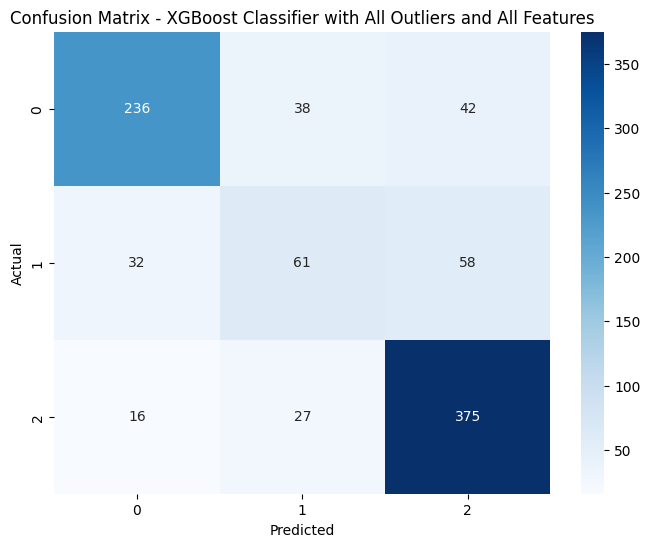

Confusion Matrix - XGBoost Classifier with All Outliers and Selected Features:


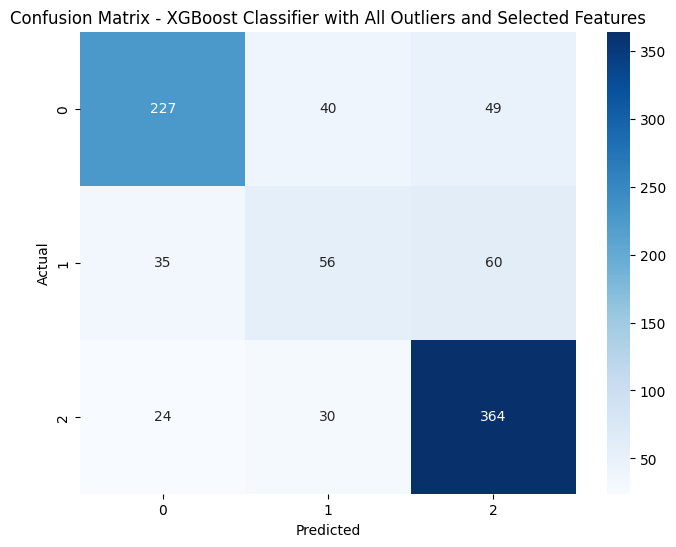

Confusion Matrix - XGBoost Classifier with No Outliers and All Features:


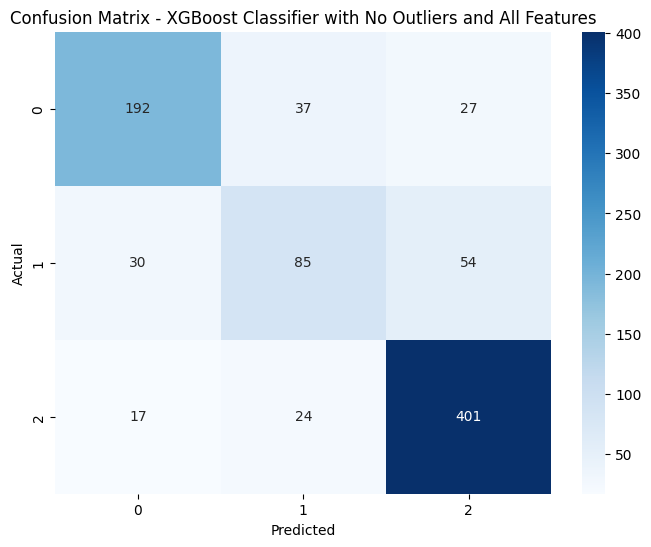

Confusion Matrix - XGBoost Classifier with No Outliers and Selected Features:


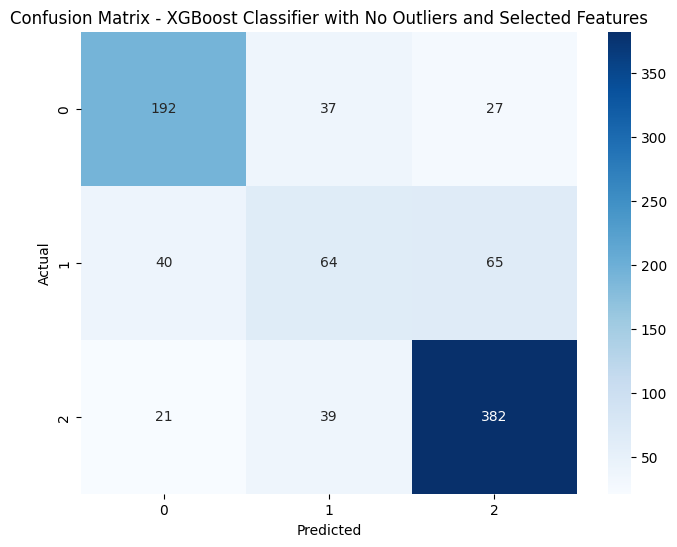

In [8]:
# Plot Confusion Matrix Chart
print("Confusion Matrix - XGBoost Classifier with All Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, xgb_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - XGBoost Classifier with All Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, xgb_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - XGBoost Classifier with No Outliers and All Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, xgb_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - XGBoost Classifier with No Outliers and Selected Features:")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, xgb_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# Accuracy Score
print("Accuracy Score - XGBoost Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, xgb_a_o_a_f_pred))
print("Accuracy Score - XGBoost Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, xgb_a_o_s_f_pred))
print("Accuracy Score - XGBoost Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, xgb_n_o_a_f_pred))
print("Accuracy Score - XGBoost Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, xgb_n_o_s_f_pred))

Accuracy Score - XGBoost Classifier with All Outliers and All Features: 0.7593220338983051
Accuracy Score - XGBoost Classifier with All Outliers and Selected Features: 0.7310734463276836
Accuracy Score - XGBoost Classifier with No Outliers and All Features: 0.7820069204152249
Accuracy Score - XGBoost Classifier with No Outliers and Selected Features: 0.7358708189158016


In [10]:
# ROC AUC Score
print("ROC AUC Score - XGBoost Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, xgb_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - XGBoost Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, xgb_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - XGBoost Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, xgb_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))
print("ROC AUC Score - XGBoost Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, xgb_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))

ROC AUC Score - XGBoost Classifier with All Outliers and All Features: 0.8711274285169449
ROC AUC Score - XGBoost Classifier with All Outliers and Selected Features: 0.8373393772302964
ROC AUC Score - XGBoost Classifier with No Outliers and All Features: 0.8983459936350983
ROC AUC Score - XGBoost Classifier with No Outliers and Selected Features: 0.8539557302964808


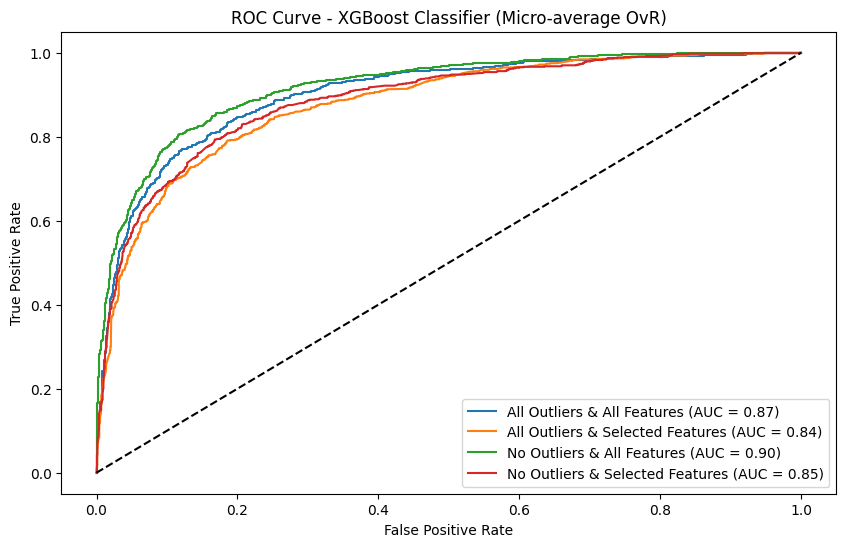

In [11]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, xgb_a_o_a_f.predict_proba(X_test_a_o_a_f), xgb_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, xgb_a_o_s_f.predict_proba(X_test_a_o_s_f), xgb_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, xgb_n_o_a_f.predict_proba(X_test_n_o_a_f), xgb_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, xgb_n_o_s_f.predict_proba(X_test_n_o_s_f), xgb_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()

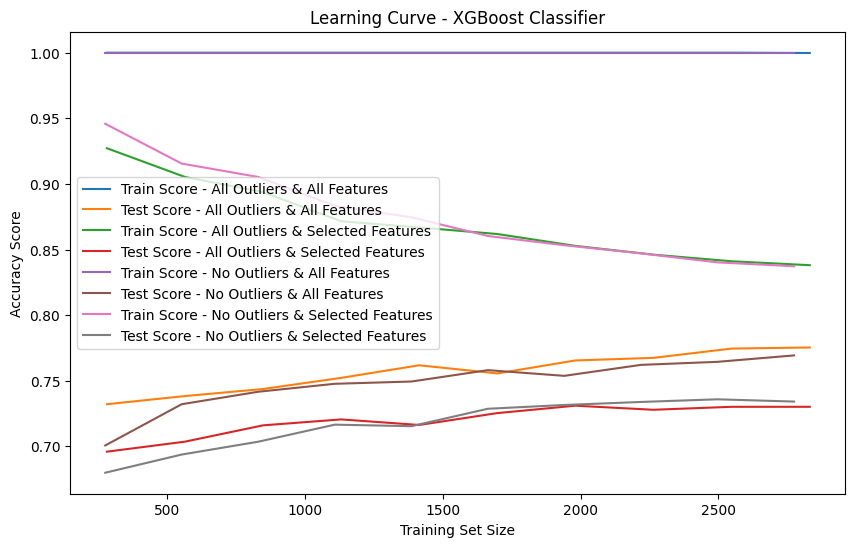

In [12]:
# Learning Curve
train_sizes_a_o_a_f, train_scores_a_o_a_f, test_scores_a_o_a_f = learning_curve(
    xgb_a_o_a_f, X_train_a_o_a_f, y_train_a_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_a_o_s_f, train_scores_a_o_s_f, test_scores_a_o_s_f = learning_curve(
    xgb_a_o_s_f, X_train_a_o_s_f, y_train_a_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_a_f, train_scores_n_o_a_f, test_scores_n_o_a_f = learning_curve(
    xgb_n_o_a_f, X_train_n_o_a_f, y_train_n_o_a_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
train_sizes_n_o_s_f, train_scores_n_o_s_f, test_scores_n_o_s_f = learning_curve(
    xgb_n_o_s_f, X_train_n_o_s_f, y_train_n_o_s_f, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_a_o_a_f, np.mean(train_scores_a_o_a_f, axis=1), label='Train Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_a_f, np.mean(test_scores_a_o_a_f, axis=1), label='Test Score - All Outliers & All Features')
plt.plot(train_sizes_a_o_s_f, np.mean(train_scores_a_o_s_f, axis=1), label='Train Score - All Outliers & Selected Features')
plt.plot(train_sizes_a_o_s_f, np.mean(test_scores_a_o_s_f, axis=1), label='Test Score - All Outliers & Selected Features')
plt.plot(train_sizes_n_o_a_f, np.mean(train_scores_n_o_a_f, axis=1), label='Train Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_a_f, np.mean(test_scores_n_o_a_f, axis=1), label='Test Score - No Outliers & All Features')
plt.plot(train_sizes_n_o_s_f, np.mean(train_scores_n_o_s_f, axis=1), label='Train Score - No Outliers & Selected Features')
plt.plot(train_sizes_n_o_s_f, np.mean(test_scores_n_o_s_f, axis=1), label='Test Score - No Outliers & Selected Features')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curve - XGBoost Classifier')
plt.legend(loc='best')
plt.show()

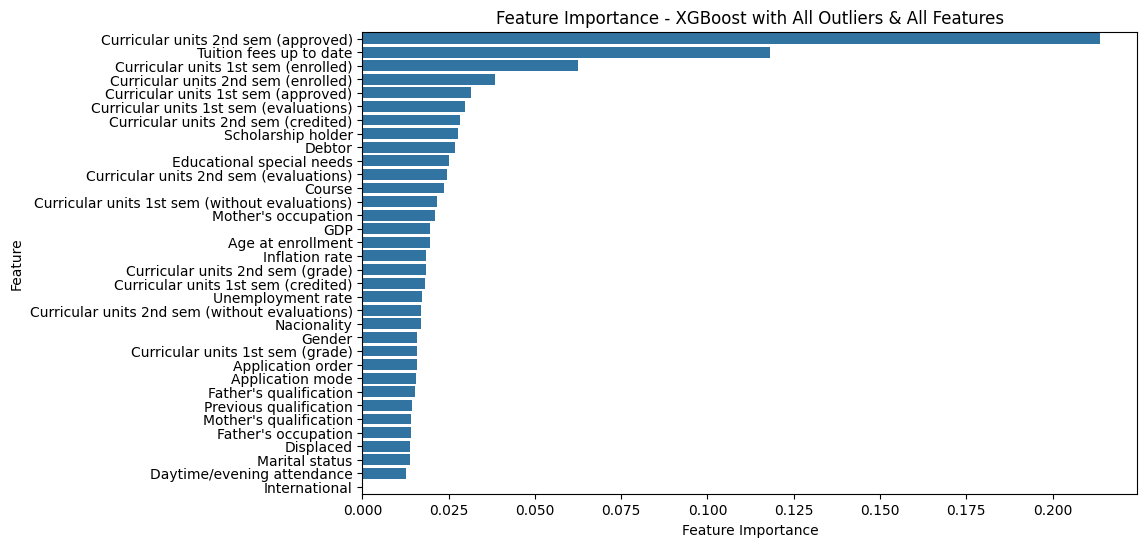

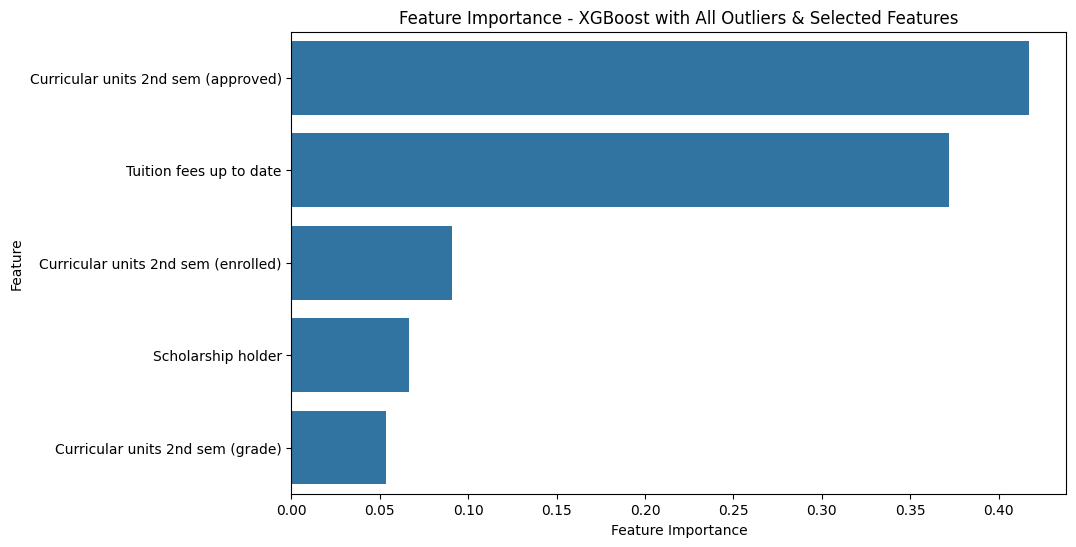

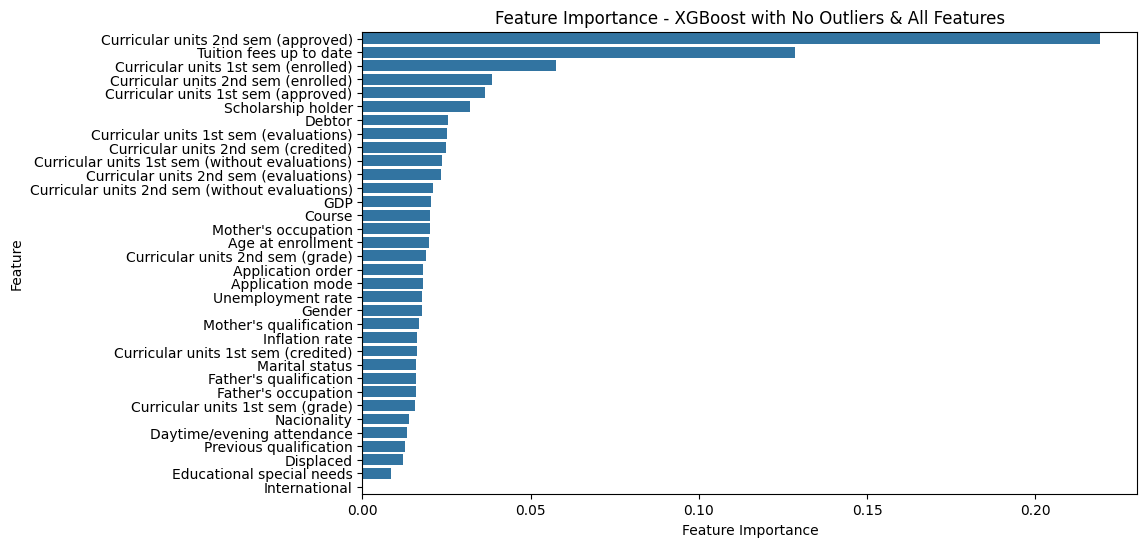

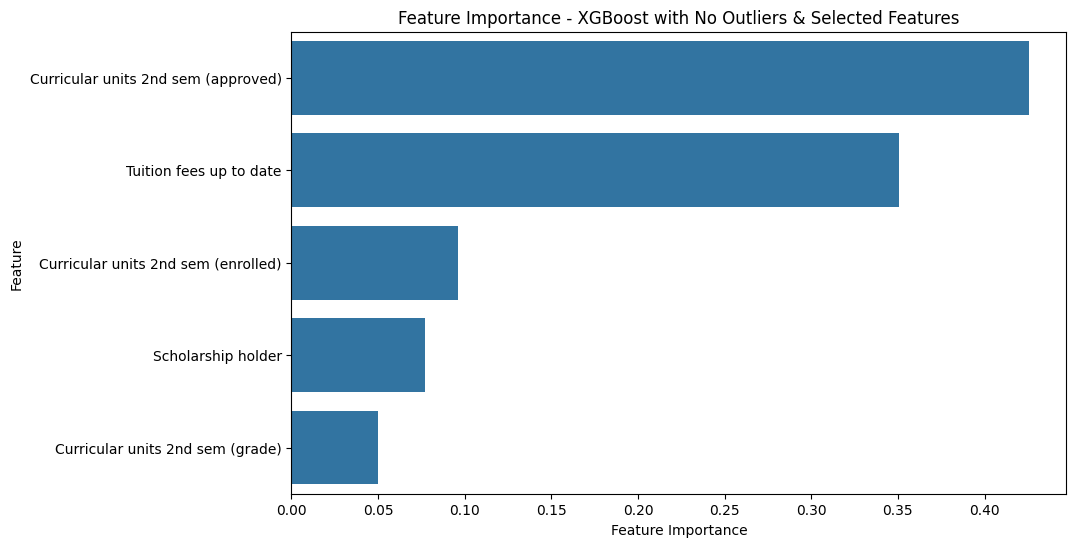

In [13]:
def plot_feature_importance(model, feature_names, title):
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance[indices], y=np.array(feature_names)[indices])
    plt.title(title)
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.show()
plot_feature_importance(xgb_a_o_a_f, X_train_a_o_a_f.columns, "Feature Importance - XGBoost with All Outliers & All Features")
plot_feature_importance(xgb_a_o_s_f, X_train_a_o_s_f.columns, "Feature Importance - XGBoost with All Outliers & Selected Features")
plot_feature_importance(xgb_n_o_a_f, X_train_n_o_a_f.columns, "Feature Importance - XGBoost with No Outliers & All Features")
plot_feature_importance(xgb_n_o_s_f, X_train_n_o_s_f.columns, "Feature Importance - XGBoost with No Outliers & Selected Features")

## **Model Evaluation Summary**
The most robust model is:
**XGBoost Classifier with No Outliers and All Features**

### Key Points:
- Achieved the highest ROC AUC with stable accuracy across all configurations.
- Consistently performs better than other configurations across evaluation metrics.
- Removing outliers improves model performance.
- Using all features provides better results than the selected feature subset.

### Overfitting Insight:
- All models show a clear gap between training and testing performance.
- Training accuracy is close to **1.00**, while testing accuracy ranges from **0.76 to 0.80**.
- This indicates that the models are **overfitting**, with limited generalization capability.

### Conclusion:
The **No Outliers & All Features** configuration is the best-performing model, although overfitting is still present.

# **XGBoost with Hyperparameter Tuning**

## **Coarse-to-Fine-Search**

### **RandomSearchCV**

In [ ]:
# param_dist_xgb = {
#     'n_estimators'      : np.arange(100, 1001, 100),
#     'max_depth'         : np.arange(3, 11),
#     'learning_rate'     : [0.01, 0.05, 0.1, 0.2, 0.3],
#     'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree'  : [0.6, 0.7, 0.8, 0.9, 1.0],
#     'min_child_weight'  : np.arange(1, 11),
#     'gamma'             : [0, 0.1, 0.2, 0.3, 0.5],
#     'reg_alpha'         : [0, 0.01, 0.1, 0.5, 1.0],
#     'reg_lambda'        : [0.5, 1.0, 1.5, 2.0, 5.0]
# }

# random_search_xgb1 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Hyperparameters for XGBoost Classifier with All Outliers and Selected Features (Randomized Search):")
# print(random_search_xgb1.best_params_)

# random_search_xgb2 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Hyperparameters for XGBoost Classifier with No Outliers and Selected Features (Randomized Search):")
# print(random_search_xgb2.best_params_)

# random_search_xgb3 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Hyperparameters for XGBoost Classifier with All Outliers and All Features (Randomized Search):")
# print(random_search_xgb3.best_params_)

# random_search_xgb4 = RandomizedSearchCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False), param_distributions=param_dist_xgb, n_iter=100, cv=5, n_jobs=-1, verbose=2, scoring='accuracy', random_state=42)
# random_search_xgb4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Hyperparameters for XGBoost Classifier with No Outliers and All Features (Randomized Search):")
# print(random_search_xgb4.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for XGBoost Classifier with All Outliers and Selected Features (Randomized Search):
{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': np.int64(300), 'min_child_weight': np.int64(1), 'max_depth': np.int64(3), 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.9}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for XGBoost Classifier with No Outliers and Selected Features (Randomized Search):
{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.01, 'n_estimators': np.int64(1000), 'min_child_weight': np.int64(9), 'max_depth': np.int64(4), 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Hyperparameters for XGBoost Classifier with All Outliers and All Features (Randomized Search):
{'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 1.0, 'n_estimators': np.int64(400)

### **GridSearchCV**

In [ ]:
# param_grid_xgb1 = {
#     'n_estimators'     : [200, 300, 400],          
#     'max_depth'        : [2, 3, 4],                
#     'learning_rate'    : [0.05, 0.1, 0.15],        
#     'min_child_weight' : [1, 2, 3],                
#     'subsample'        : [0.8, 0.9, 1.0],          
#     'colsample_bytree' : [0.9],          
#     'gamma'            : [0.5],          
#     'reg_alpha'        : [0.5],          
#     'reg_lambda'       : [2.0],          
# }

# grid_xgb1 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb1, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb1.fit(X_train_a_o_s_f, y_train_a_o_s_f)
# print("Best Params XGB1:", grid_xgb1.best_params_)
# print("Best Score  XGB1:", grid_xgb1.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB1: {'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 1.0}
Best Score  XGB1: 0.759537793973102


In [ ]:
# param_grid_xgb2 = {
#     'n_estimators'     : [800, 1000, 1200],    
#     'max_depth'        : [3, 4, 5],            
#     'learning_rate'    : [0.005, 0.01, 0.05],  
#     'min_child_weight' : [7, 9, 11],           
#     'subsample'        : [0.8, 0.9, 1.0],                
#     'colsample_bytree' : [0.7],                
#     'gamma'            : [0.5],                
#     'reg_alpha'        : [0.01],               
#     'reg_lambda'       : [2.0],                
# }

# grid_xgb2 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb2.fit(X_train_n_o_s_f, y_train_n_o_s_f)
# print("Best Params XGB2:", grid_xgb2.best_params_)
# print("Best Score  XGB2:", grid_xgb2.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB2: {'colsample_bytree': 0.7, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 1000, 'reg_alpha': 0.01, 'reg_lambda': 2.0, 'subsample': 1.0}
Best Score  XGB2: 0.7572089773818881


In [ ]:
# param_grid_xgb3 = {
#     'n_estimators'     : [300, 400, 500],          
#     'max_depth'        : [2, 3, 4],                
#     'learning_rate'    : [0.05, 0.1, 0.15],        
#     'min_child_weight' : [3, 4, 5],                
#     'subsample'        : [0.8, 0.9, 1.0],          
#     'colsample_bytree' : [0.7],          
#     'gamma'            : [0],            
#     'reg_alpha'        : [1.0],          
#     'reg_lambda'       : [1.5],          
# }

# grid_xgb3 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb3, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb3.fit(X_train_a_o_a_f, y_train_a_o_a_f)
# print("Best Params XGB3:", grid_xgb3.best_params_)
# print("Best Score  XGB3:", grid_xgb3.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB3: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.15, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 400, 'reg_alpha': 1.0, 'reg_lambda': 1.5, 'subsample': 0.9}
Best Score  XGB3: 0.7860978591805912


In [ ]:
# param_grid_xgb4 = {
#     'n_estimators'     : [300, 400, 500],          
#     'max_depth'        : [2, 3, 4],                
#     'learning_rate'    : [0.1, 0.2, 0.3],          
#     'min_child_weight' : [4, 5, 6],                
#     'subsample'        : [0.8, 0.9, 1.0],          
#     'colsample_bytree' : [0.6],          
#     'gamma'            : [0.5],            
#     'reg_alpha'        : [0.01],        
#     'reg_lambda'       : [1.5],          
# }

# grid_xgb4 = GridSearchCV(
#     XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
#     param_grid_xgb4, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
# )
# grid_xgb4.fit(X_train_n_o_a_f, y_train_n_o_a_f)
# print("Best Params XGB4:", grid_xgb4.best_params_)
# print("Best Score  XGB4:", grid_xgb4.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Params XGB4: {'colsample_bytree': 0.6, 'gamma': 0.5, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1.5, 'subsample': 1.0}
Best Score  XGB4: 0.7828723629876368


#### **Note: GridSearchCV Configuration**

The original configuration was **not used** due to hardware limitations (Axioo Hype 5 AMD — Ryzen 5 6600H, no CUDA GPU). The full grid would generate **98,415 fits** and take approximately **90–150 minutes** to complete, causing 100% CPU usage.

The following code was **skipped**:

```python
# ❌ NOT USED — Estimated runtime: ~90–150 minutes | Total fits: 98,415 | CPU: ~100%
param_grid_xgb2 = {
    'n_estimators'     : [800, 1000, 1200],
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.005, 0.01, 0.05],
    'subsample'        : [0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8],
    'min_child_weight' : [7, 9, 11],
    'gamma'            : [0.3, 0.5, 0.7],
    'reg_alpha'        : [0.01, 0.05, 0.1],
    'reg_lambda'       : [1.5, 2.0, 2.5],
}
grid_xgb2 = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    param_grid_xgb2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
```

Instead, the optimized configuration below was used by fixing parameters already validated by RandomizedSearchCV (`subsample`, `colsample_bytree`, `gamma`, `reg_alpha`, `reg_lambda`) and only searching the 4 highest-impact parameters, reducing total fits from **98,415 → 405** with actual runtime of only **~1–2 minutes**.

```python
# ✅ USED — Actual runtime: ~1–2 minutes | Total fits: 405 | CPU: ~60–80%
param_grid_xgb2 = {
    'n_estimators'     : [800, 1000, 1200],
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.005, 0.01, 0.05],
    'min_child_weight' : [7, 9, 11],
    'subsample'        : [1.0],            # fixed from RandomizedSearch
    'colsample_bytree' : [0.7],            # fixed from RandomizedSearch
    'gamma'            : [0.5],            # fixed from RandomizedSearch
    'reg_alpha'        : [0.01],           # fixed from RandomizedSearch
    'reg_lambda'       : [2.0],            # fixed from RandomizedSearch
}
grid_xgb2 = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    param_grid_xgb2, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
```

## **IMPLEMENTATION TO THE MODELS WITH THE RESULTS OF** ***Coarse-to-Fine-Search***